# Radar plots — MRR per model

Single notebook for all KGs. **Pick the KG in the config cell below**, then *Run All*.

All reusable code lives in `radar_plots.py`; all KG-specific settings (paths,
relations, `y_lim`) live in `kg_configs.py`.

Figures produced:
1. **DL1** — With / Without DL1 (Global, Redundant, Indication)
2. **DL2** — Unpermuted / Permuted indication (Indication, Global)
3. **DL3** — Test vs Independent test set + Indication by entity frequency
4. **Made-directed relations** — per-relation-type breakdown (KG-specific)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import radar_plots as rp
from kg_configs import CONFIGS

# ===> PICK THE KG HERE: 'biokg' | 'hetionet' | 'shepkg' <===
KG = "biokg"

cfg = CONFIGS[KG]
print(f"KG = {cfg.name}  |  figures -> {cfg.figures_dir}")

KG = hetionet  |  figures -> /home/galadriel/dr_benchmark/Figures/HetionetKG


In [2]:
# Load the metrics (DL1 / DL2 / zero-shot). 'best' = max over run1/run2.
results = rp.parse_model_metrics(cfg.dl_experiments, cfg)

# Sanity check: models found, in display order.
models = rp.order_models(results["without_dl1"]["best"], cfg.model_order)
print(f"{len(models)} models:", models)

7 models: ['ANALOGY', 'ComplEx', 'HolE', 'RESCAL', 'DistMult', 'TransE', 'TransD']


## Figure 1 — DL1: With vs Without DL1

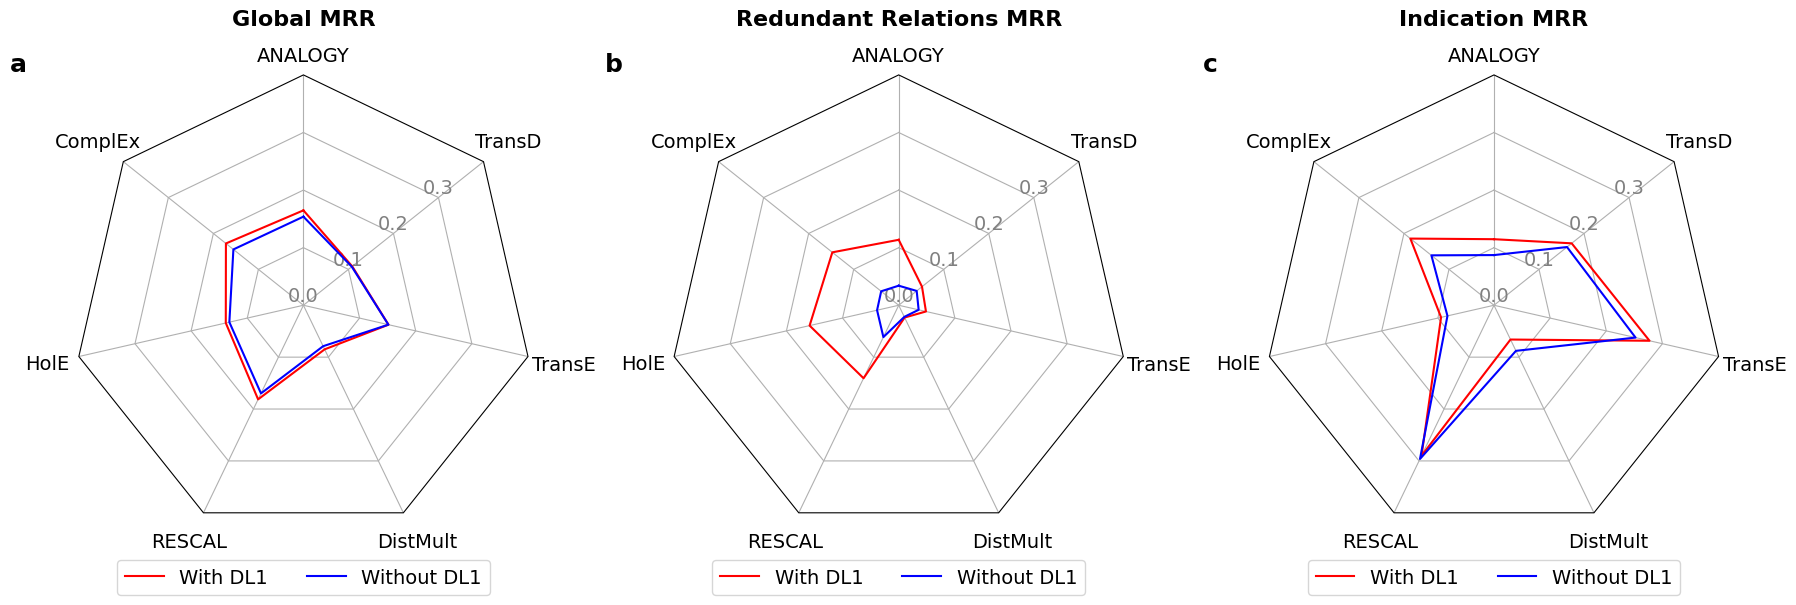

In [3]:
rp.radar_factory(len(models), frame="polygon")
fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(projection="radar"))

panels = [
    ("Global MRR",              "global_mrr"),
    ("Redundant Relations MRR", "made_directed_relations"),
    ("Indication MRR",          "target_relations"),
]
for i, (title, metric) in enumerate(panels):
    rp.plot_radar(
        results, experiment1="with_dl1", experiment2="without_dl1", run="best",
        metric1=metric, y_lim=cfg.ylims["fig1"], title=title,
        legend_labels=["With DL1", "Without DL1"], colors=("red", "blue"),
        show=False, ax=axs[i], panel_label=chr(97 + i),
    )

plt.tight_layout()
plt.savefig(f"{cfg.figures_dir}/DL1_{cfg.name}.pdf", bbox_inches="tight")
plt.show()

## Figure 2 — DL2: Unpermuted vs Permuted indication

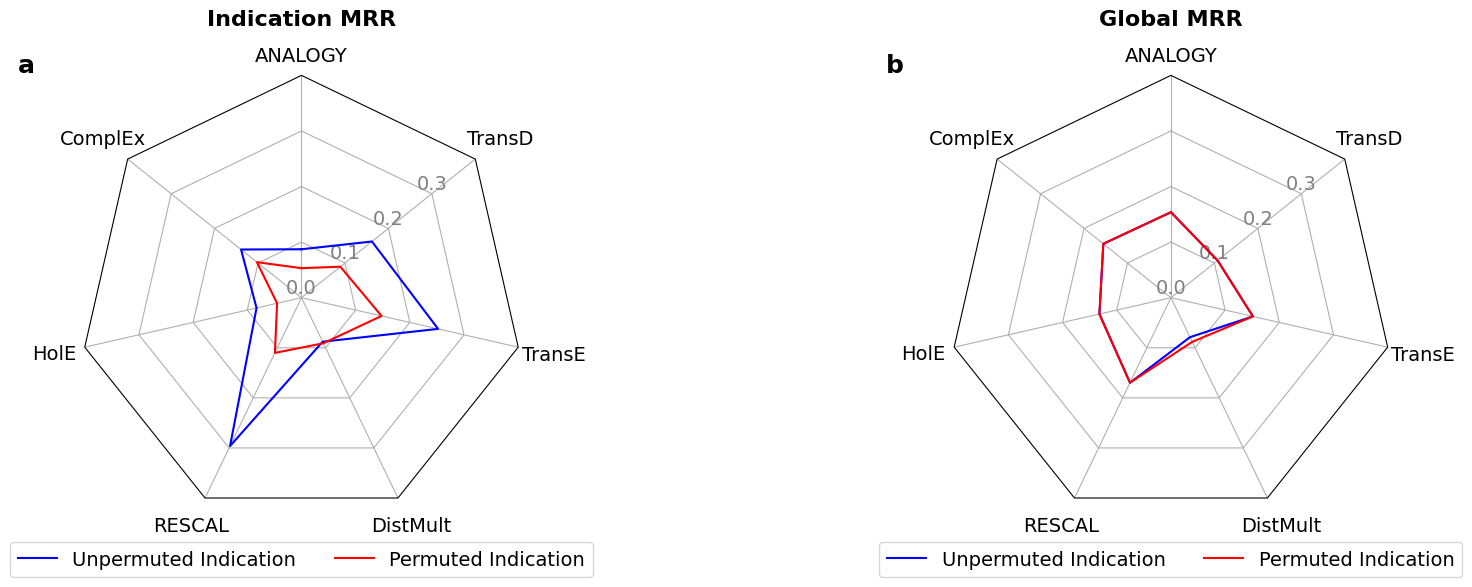

In [4]:
rp.radar_factory(len(models), frame="polygon")
fig, axs = plt.subplots(1, 2, figsize=(18, 6), subplot_kw=dict(projection="radar"))

panels = [
    ("Indication MRR", "target_relations"),
    ("Global MRR",     "global_mrr"),
]
for i, (title, metric) in enumerate(panels):
    rp.plot_radar(
        results, experiment1="without_dl1", experiment2="dl2", run="best",
        metric1=metric, y_lim=cfg.ylims["fig2"], title=title,
        legend_labels=["Unpermuted Indication", "Permuted Indication"],
        colors=("blue", "red"), show=False, ax=axs[i], panel_label=chr(97 + i),
    )

plt.tight_layout()
plt.savefig(f"{cfg.figures_dir}/DL2_{cfg.name}.pdf", bbox_inches="tight")
plt.show()

## Figure 3 — DL3: test vs independent test set, and by indication frequency

(Panel labels 'a' / 'c' reproduce the figure numbering from the paper.)

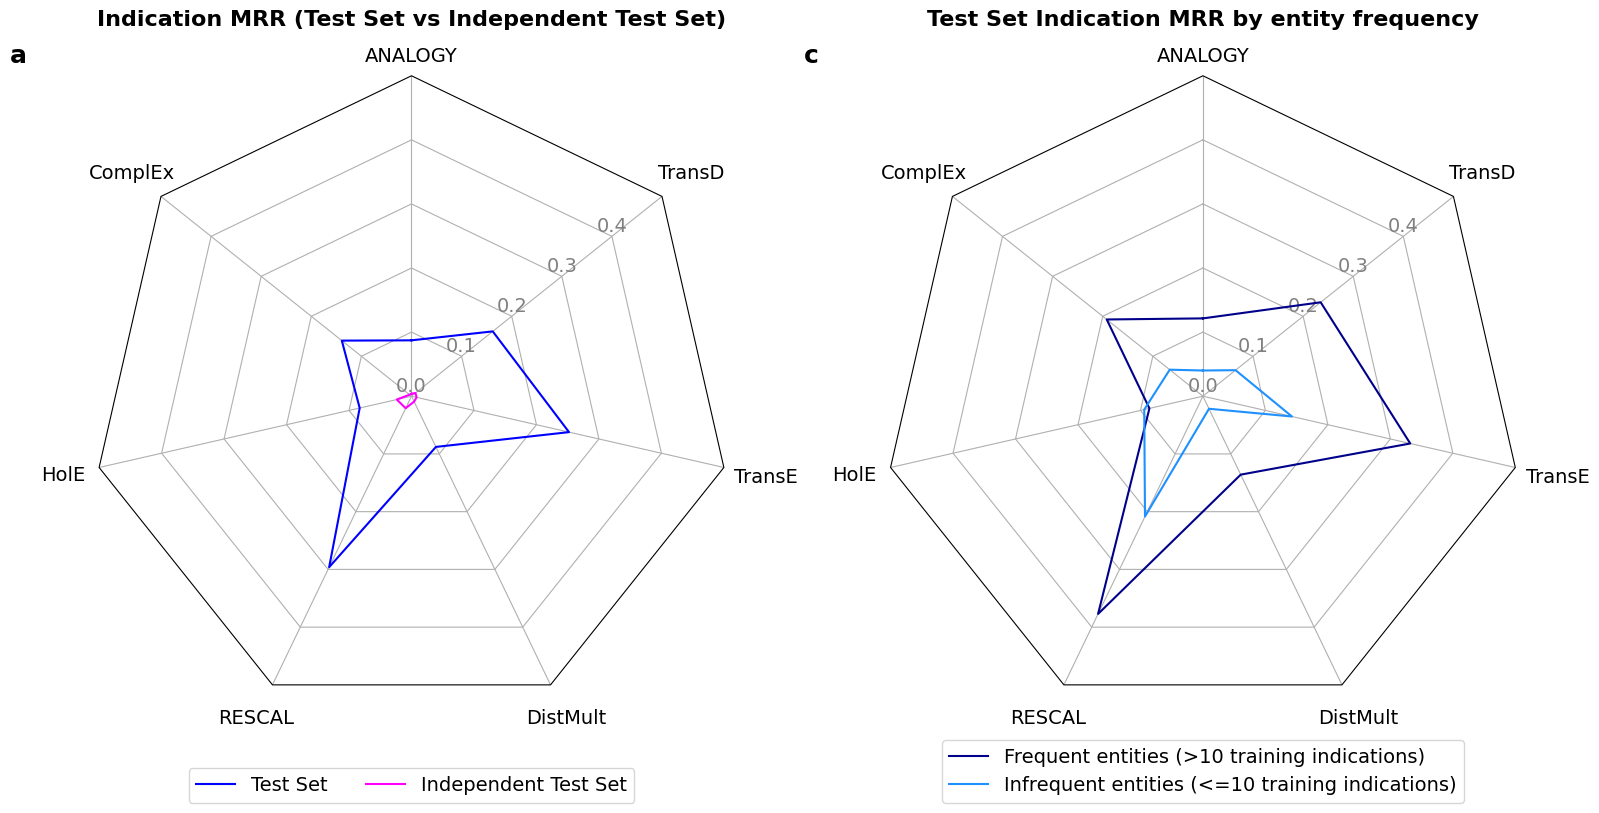

In [5]:
rp.radar_factory(len(models), frame="polygon")
fig, axs = plt.subplots(1, 2, figsize=(16, 8), subplot_kw=dict(projection="radar"))

# Panel a: Test set vs Independent test set
rp.plot_radar(
    results, experiment1="without_dl1", run="best",
    metric1="target_relations", metric2="inference_mrr",
    y_lim=cfg.ylims["fig3_test_vs_inf"],
    title="Indication MRR (Test Set vs Independent Test Set)",
    legend_labels=["Test Set", "Independent Test Set"],
    colors=("blue", "fuchsia"), show=False, ax=axs[0], panel_label="a",
)

# Panel c: Indication MRR by entity frequency
rp.plot_radar(
    results, experiment1="without_dl1", run="best",
    metric1="target_frequent", metric2="target_infrequent",
    y_lim=cfg.ylims["fig3_freq"],
    title="Test Set Indication MRR by entity frequency",
    legend_labels=["Frequent entities (>10 training indications)",
                   "Infrequent entities (<=10 training indications)"],
    colors=("darkblue", "dodgerblue"), show=False, ax=axs[1], panel_label="c", legend_ncol=1,
)

plt.tight_layout()
plt.savefig(f"{cfg.figures_dir}/DL3_{cfg.name}.pdf", bbox_inches="tight")
plt.show()

## Figure 4 — Made-directed relations (KG-specific breakdown)

The number of panels and the relation types depend on the KG
(see `cfg.directed_relations` in `kg_configs.py`).

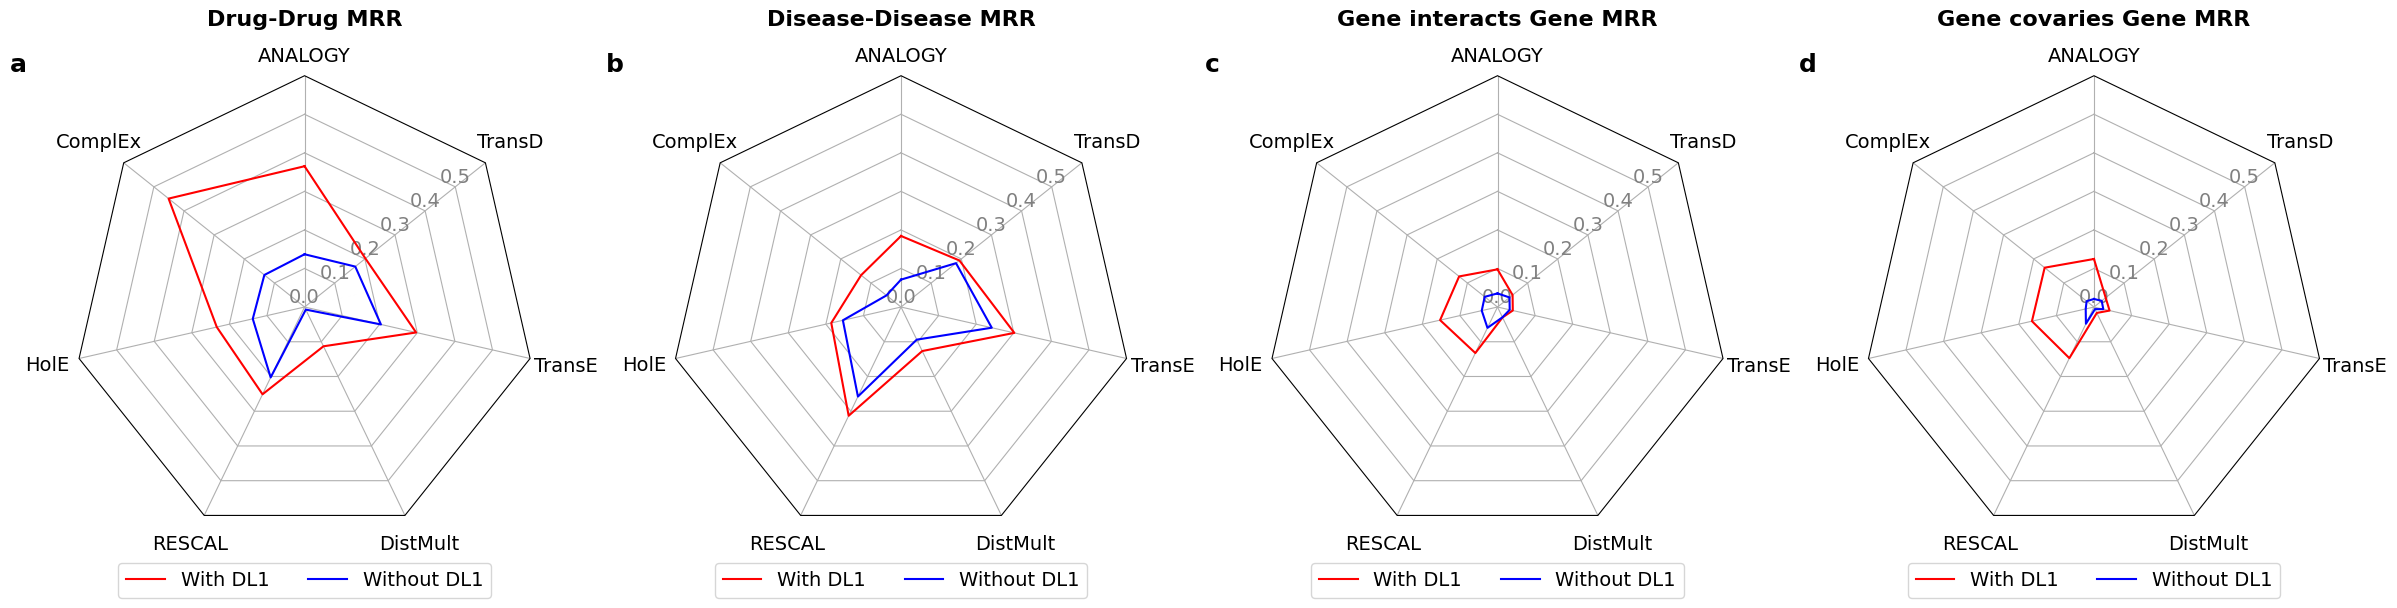

In [6]:
dr = cfg.directed_relations           # ordered dict: metric -> {keys, title}
metrics = list(dr.keys())

rp.radar_factory(len(models), frame="polygon")
fig, axs = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 6),
                        subplot_kw=dict(projection="radar"))
axs = np.atleast_1d(axs)

for i, metric in enumerate(metrics):
    rp.plot_radar(
        results, experiment1="with_dl1", experiment2="without_dl1", run="best",
        metric1=metric, y_lim=cfg.ylims["directed"], title=dr[metric]["title"],
        legend_labels=["With DL1", "Without DL1"], colors=("red", "blue"),
        show=False, ax=axs[i], panel_label=chr(97 + i),
    )

plt.tight_layout()
plt.savefig(f"{cfg.figures_dir}/{cfg.name}_directed_relations.pdf", bbox_inches="tight")
plt.show()